# **LAB 03**


---



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

# **Lab Task 1: Dataset Loading and Visualization**


---


1. Select and load a suitable binary-classification dataset from Kaggle or the UCI Machine Learning
Repository.
2. Perform basic data inspection, including dataset shape, features, target variable, and missing values.
3. Visualize the dataset using appropriate plots to understand the distribution of the classes.
4. Split the dataset into training and testing sets and prepare the features for model training.

In [2]:
# Task 1.1: Load Dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("Target Classes:", data.target_names)

Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


In [ ]:
# Task 1.2: Data Inspection

print("Shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(data.target_names)

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nFirst 5 Rows:")
display(X.head())

target
1    357
0    212
Name: count, dtype: int64


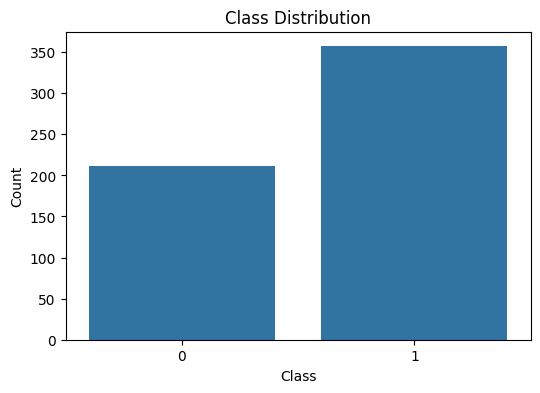

In [3]:
# Task 1.3: Class Distribution

print(y.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [9]:
# Task 1.4: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (455, 30)
Testing: (114, 30)


# **Lab Task 2: Basic Perceptron Implementation**


---


1. Implement a Perceptron classifier from scratch using Python and NumPy, without using a built-in
Perceptron classifier.
2. Initialize the weights and bias and implement the perceptron prediction and weight-update rules.
3. Train the perceptron on the training dataset for a specified number of epochs.
4. Evaluate the trained perceptron on the test dataset and report its classification accuracy.


In [21]:
import numpy as np

# Task 2.1: Perceptron

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.errors_ = [] # Initialize errors_ here

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        # self.errors_ = [] # Remove initialization from here, as it's now in __init__

        for epoch in range(self.epochs):
            errors = 0

            for xi, target in zip(X, y):
                prediction = self.predict(xi)

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors_.append(errors)

        return self

    def predict(self, X):
        return np.where(
            np.dot(X, self.weights) + self.bias >= 0,
            1,
            0
        )

In [11]:
# Task 2.2: Initialize

model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

model.weights = np.zeros(X_train.shape[1])
model.bias = 0

print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Bias: 0


In [45]:
# Task 2.3: Training

model.fit(X_train, y_train)

print("Training completed.")
print("Epochs:", model.epochs)

default_convergence = next(
    (i + 1 for i, e in enumerate(model.errors_) if e == 0),
    "Not converged"
)
print("Default Model Convergence Epoch:", default_convergence)

Training completed.
Epochs: 100
Default Model Convergence Epoch: Not converged


In [13]:
# Task 2.4: Evaluation

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9473684210526315
Accuracy (%): 94.73684210526315

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



# **Lab Task 3: Perceptron Learning Curve and Weight Visualization**


---


1. Modify your perceptron implementation to record the training error/loss after every epoch.
2. Plot the learning curve showing the change in error over training epochs.
3. Display the final values of the weights and bias after training.
4. Visualize the final decision boundary, where applicable, and explain how it separates the two classes.

In [14]:
# Task 3.1: Training Error

print("Training Errors:")
print(model.errors_)

Training Errors:
[25, 15, 20, 10, 13, 9, 13, 16, 10, 12, 10, 8, 11, 11, 12, 9, 11, 16, 8, 10, 13, 13, 8, 7, 13, 8, 13, 9, 7, 9, 10, 9, 13, 11, 9, 12, 9, 12, 11, 10, 12, 9, 8, 9, 11, 10, 10, 12, 8, 13, 9, 9, 9, 12, 10, 7, 9, 8, 8, 10, 8, 9, 12, 9, 9, 9, 12, 10, 7, 8, 12, 11, 7, 8, 11, 8, 11, 10, 7, 11, 8, 12, 10, 10, 8, 11, 9, 9, 13, 10, 7, 10, 8, 13, 12, 6, 11, 10, 9, 11]


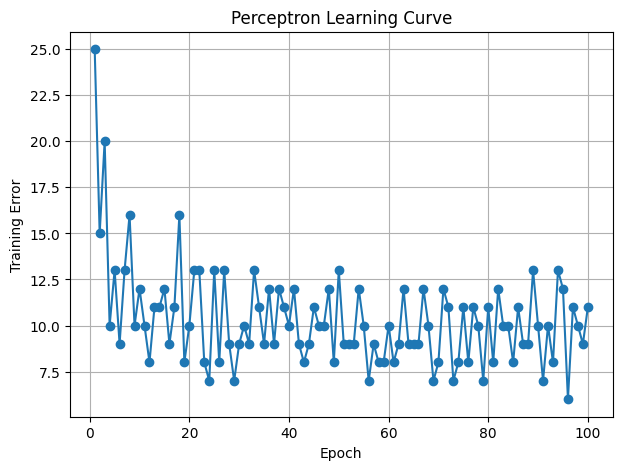

In [15]:
# Task 3.2: Learning Curve

plt.figure(figsize=(7,5))
plt.plot(range(1, len(model.errors_) + 1), model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Error")
plt.title("Perceptron Learning Curve")
plt.grid()
plt.show()

In [16]:
# Task 3.3: Final Weights

print("Final Weights:")
print(model.weights)

print("\nFinal Bias:")
print(model.bias)

Final Weights:
[-0.01580631 -0.00756866 -0.01251949 -0.04603295 -0.04525825  0.34070327
 -0.14415369 -0.09652193  0.04278064 -0.1261977  -0.11743002  0.04944377
  0.07718848 -0.20226512 -0.03395814 -0.09693805  0.3015154  -0.14828711
  0.02717231  0.08577086 -0.09546536 -0.14691481 -0.01655042 -0.16520334
 -0.01104277  0.042668   -0.2721711   0.00735376 -0.14134638  0.07280957]

Final Bias:
-0.04


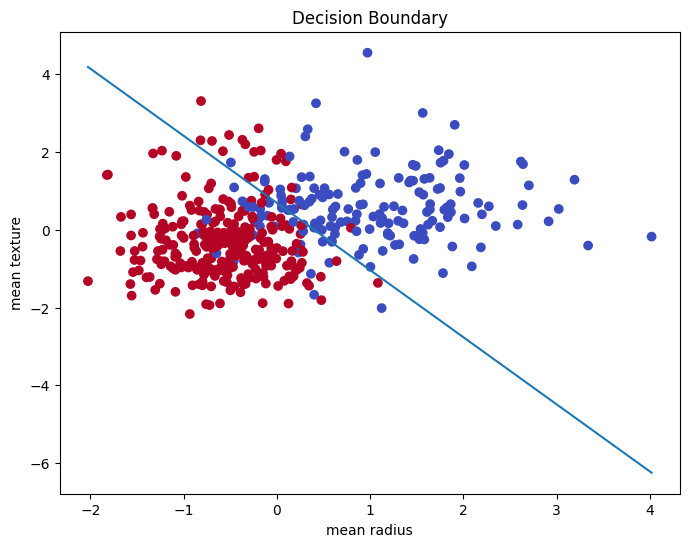

In [17]:
# Task 3.4: Decision Boundary

X_2d = X_train[:, :2]

model_2d = Perceptron(learning_rate=0.01, epochs=100)
model_2d.fit(X_2d, y_train)

plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=y_train,
    cmap="coolwarm"
)

x_values = np.linspace(
    X_2d[:,0].min(),
    X_2d[:,0].max(),
    100
)

y_values = (
    -(model_2d.weights[0] * x_values)
    - model_2d.bias
) / model_2d.weights[1]

plt.plot(x_values, y_values)
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Decision Boundary")
plt.show()

# **Lab Task 4: Gaussian Weight Initialization**


---


1. Re-initialize the perceptron&#39;s weights using Gaussian/Normal initialization with a suitable mean and
standard deviation.
2. Train the perceptron using the same dataset, hyperparameters, and training procedure used previously.
3. Record the number of epochs required for the perceptron to converge and plot its learning curve.
4. Compare the Gaussian-initialized model with the default/randomly initialized model in terms of
convergence and final weights.


In [18]:
# Task 4.1: Gaussian Initialization

def gaussian_init(n):
    return np.random.normal(0, 0.01, n)

gaussian_weights = gaussian_init(X_train.shape[1])

print("Gaussian Weights:")
print(gaussian_weights)

Gaussian Weights:
[ 0.00496714 -0.00138264  0.00647689  0.0152303  -0.00234153 -0.00234137
  0.01579213  0.00767435 -0.00469474  0.0054256  -0.00463418 -0.0046573
  0.00241962 -0.0191328  -0.01724918 -0.00562288 -0.01012831  0.00314247
 -0.00908024 -0.01412304  0.01465649 -0.00225776  0.00067528 -0.01424748
 -0.00544383  0.00110923 -0.01150994  0.00375698 -0.00600639 -0.00291694]


In [25]:
# Task 4.2: Gaussian Training

gaussian_model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

gaussian_model.weights = gaussian_weights.copy()
gaussian_model.bias = 0

for epoch in range(gaussian_model.epochs):
    errors = 0

    for xi, target in zip(X_train, y_train):
        prediction = gaussian_model.predict(xi)
        update = gaussian_model.learning_rate * (target - prediction)

        gaussian_model.weights += update * xi
        gaussian_model.bias += update

        if update != 0:
            errors += 1

    gaussian_model.errors_.append(errors)

print("Gaussian training completed.")

Gaussian training completed.


Convergence Epoch: Not converged


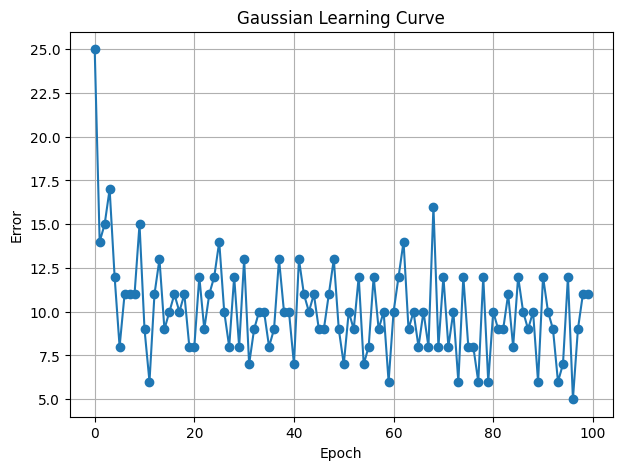

In [71]:
# Task 4.3: Convergence

gaussian_convergence = next(
    (i + 1 for i, e in enumerate(gaussian_model.errors_) if e == 0),
    "Not converged"
)

print("Convergence Epoch:", gaussian_convergence)

plt.figure(figsize=(7,5))
plt.plot(gaussian_model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Gaussian Learning Curve")
plt.grid()
plt.show()



In [24]:
# Task 4.4: Comparison

default_accuracy = accuracy_score(
    y_test,
    model.predict(X_test)
)

gaussian_accuracy = accuracy_score(
    y_test,
    gaussian_model.predict(X_test)
)

print("Default Accuracy:", default_accuracy)
print("Gaussian Accuracy:", gaussian_accuracy)

print("\nDefault Weights:")
print(model.weights)

print("\nGaussian Weights:")
print(gaussian_model.weights)

Default Accuracy: 0.9473684210526315
Gaussian Accuracy: 0.9473684210526315

Default Weights:
[-0.01580631 -0.00756866 -0.01251949 -0.04603295 -0.04525825  0.34070327
 -0.14415369 -0.09652193  0.04278064 -0.1261977  -0.11743002  0.04944377
  0.07718848 -0.20226512 -0.03395814 -0.09693805  0.3015154  -0.14828711
  0.02717231  0.08577086 -0.09546536 -0.14691481 -0.01655042 -0.16520334
 -0.01104277  0.042668   -0.2721711   0.00735376 -0.14134638  0.07280957]

Gaussian Weights:
[-0.01529343  0.00627442 -0.00594726 -0.03098549 -0.03931289  0.35701225
 -0.13001886 -0.11944831  0.06504398 -0.11689882 -0.11772077  0.05028486
  0.09250818 -0.20709449  0.00558237 -0.11709057  0.27647028 -0.17438318
  0.01633293  0.08623516 -0.07470995 -0.1661699  -0.00517202 -0.16682949
  0.01186804  0.0504332  -0.28005979  0.00571279 -0.13791872  0.03833855]


# **Lab Task 5: Xavier/Glorot Initialization**


---


1. Implement Xavier/Glorot initialization for the perceptron&#39;s weights.
2. Train the perceptron using Xavier-initialized weights while keeping the dataset and training settings
unchanged.
3. Record the number of epochs required for convergence and plot the corresponding learning curve.
4. Compare the results with Gaussian initialization and discuss how the initialization affected the training
process.

In [47]:
# Task 5.1: Xavier/Glorot Initialization
def xavier_init(n_in, n_out=None):
    # For a single neuron, n_out is not directly applicable in the standard formula
    # Using n_in for Xavier/Glorot as it's typically for the fan-in in a layer.
    # The standard formula for Glorot is sqrt(2 / (n_in + n_out)),
    # but for a single perceptron, it's often simplified to sqrt(1 / n_in) or similar
    # to keep variance consistent.
    # Here we'll use a simplified version, considering n_in as the number of features.
    limit = np.sqrt(1 / n_in)
    return np.random.uniform(low=-limit, high=limit, size=n_in)

xavier_weights = xavier_init(X_train.shape[1])

print("Xavier Weights:")
print(xavier_weights)

Xavier Weights:
[-0.16793498 -0.1767423   0.01580739 -0.17020383  0.05750526  0.01274463
  0.06081853 -0.02141935 -0.08308168  0.16419588  0.08335221 -0.18026501
 -0.14630481  0.04808721 -0.07739801 -0.03373179  0.10280063 -0.05325852
  0.15548332  0.08049773  0.01896086 -0.11649517 -0.03301256  0.09599086
  0.17921366 -0.15568014 -0.13336949  0.08765194  0.12187972 -0.15015892]


In [48]:
# Task 5.2: Xavier Training

xavier_model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

xavier_model.weights = xavier_weights.copy()
xavier_model.bias = 0

for epoch in range(xavier_model.epochs):
    errors = 0

    for xi, target in zip(X_train, y_train):
        prediction = xavier_model.predict(xi)
        update = xavier_model.learning_rate * (target - prediction)

        xavier_model.weights += update * xi
        xavier_model.bias += update

        if update != 0:
            errors += 1

    xavier_model.errors_.append(errors)

print("Xavier training completed.")

Xavier training completed.


Xavier Convergence Epoch: Not converged


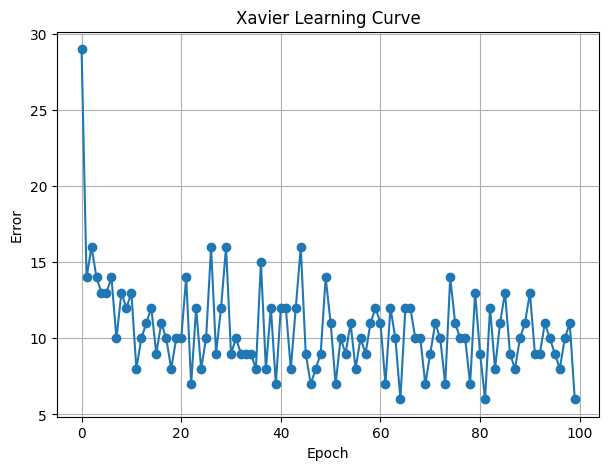

In [49]:
# Task 5.3: Convergence and Learning Curve
xavier_convergence = next(
    (i + 1 for i, e in enumerate(xavier_model.errors_) if e == 0),
    "Not converged"
)

print("Xavier Convergence Epoch:", xavier_convergence)

plt.figure(figsize=(7,5))
plt.plot(xavier_model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Xavier Learning Curve")
plt.grid()
plt.show()

# Task 5.4: Comparison

In [50]:
# Task 5.4: Comparison
xavier_accuracy = accuracy_score(
    y_test,
    xavier_model.predict(X_test)
)

print("Gaussian Accuracy:", gaussian_accuracy)
print("Xavier Accuracy:", xavier_accuracy)

print("\nGaussian Weights:")
print(gaussian_model.weights)

print("\nXavier Weights:")
print(xavier_model.weights)

Gaussian Accuracy: 0.9473684210526315
Xavier Accuracy: 0.9649122807017544

Gaussian Weights:
[-0.01529343  0.00627442 -0.00594726 -0.03098549 -0.03931289  0.35701225
 -0.13001886 -0.11944831  0.06504398 -0.11689882 -0.11772077  0.05028486
  0.09250818 -0.20709449  0.00558237 -0.11709057  0.27647028 -0.17438318
  0.01633293  0.08623516 -0.07470995 -0.1661699  -0.00517202 -0.16682949
  0.01186804  0.0504332  -0.28005979  0.00571279 -0.13791872  0.03833855]

Xavier Weights:
[-0.07743355  0.03979663  0.10969291 -0.13021705 -0.0562445   0.34758194
 -0.12709215 -0.11334942  0.03651452 -0.1257709  -0.10996176  0.05873272
  0.05483482 -0.19397827 -0.0171239  -0.13261928  0.28604868 -0.15895671
  0.02043138  0.05864164 -0.08101421 -0.18315543 -0.01374257 -0.07663706
  0.03064576  0.04747687 -0.33786632  0.00696476 -0.12076803  0.03713865]


# **Lab Task 6: He/Kaiming Initialization**


---


1. Implement He/Kaiming initialization for the perceptron&#39;s weights.
2. Train the perceptron using the He-initialized weights on the same training dataset.
3. Record the convergence behavior, number of epochs, final weights, and test accuracy.

4. Compare the He initialization results with Gaussian and Xavier initialization.


In [51]:
# Task 6.1: He/Kaiming Initialization
def he_init(n_in):
    return np.random.randn(n_in) * np.sqrt(2 / n_in)

he_weights = he_init(X_train.shape[1])

print("He Weights:")
print(he_weights)

He Weights:
[ 0.0623115   0.12470777  0.14327292 -0.28087632  0.33026622 -0.53110164
 -0.22036281 -0.1210405   0.24004365  0.11882532 -0.04843333  0.03119125
 -0.22353794  0.10991667  0.03300087 -0.10929791 -0.13665793 -0.30862043
 -0.21256768 -0.18642175 -0.09175378 -0.08267593 -0.02191791  0.17150629
  0.01453428  0.53932734 -0.23837866  0.16642134  0.04293691  0.19707207]


In [52]:
# Task 6.2: He Training
he_model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

he_model.weights = he_weights.copy()
he_model.bias = 0

for epoch in range(he_model.epochs):
    errors = 0

    for xi, target in zip(X_train, y_train):
        prediction = he_model.predict(xi)
        update = he_model.learning_rate * (target - prediction)

        he_model.weights += update * xi
        he_model.bias += update

        if update != 0:
            errors += 1

    he_model.errors_.append(errors)

print("He training completed.")

He training completed.


He Convergence Epoch: Not converged


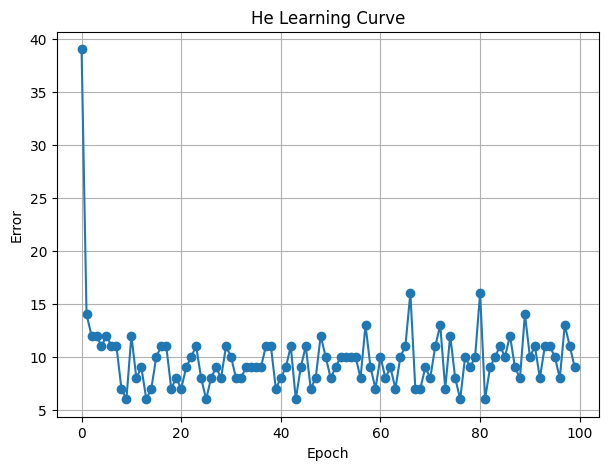

In [65]:
# Task 6.3: Convergence, Final Weights and Accuracy
he_convergence = next(
    (i + 1 for i, e in enumerate(he_model.errors_) if e == 0),
    "Not converged"
)

print("He Convergence Epoch:", he_convergence)

plt.figure(figsize=(7,5))
plt.plot(he_model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("He Learning Curve")
plt.grid()
plt.show()


In [72]:
# Task 6.3:Comaprison
he_accuracy = accuracy_score(
    y_test,
    he_model.predict(X_test)
)
print("\nDefault Accuracy:", default_accuracy)
print("Gaussian Accuracy:", gaussian_accuracy)
print("Xavier Accuracy:", xavier_accuracy)
print("He Accuracy:", he_accuracy)

print("\nDefault Weights:")
print(model.weights)

print("\nGaussian Weights:")
print(gaussian_model.weights)

print("\nXavier Weights:")
print(xavier_model.weights)

print("\nHe Weights:")
print(he_model.weights)


Default Accuracy: 0.9473684210526315
Gaussian Accuracy: 0.9473684210526315
Xavier Accuracy: 0.9649122807017544
He Accuracy: 0.9649122807017544

Default Weights:
[-0.01580631 -0.00756866 -0.01251949 -0.04603295 -0.04525825  0.34070327
 -0.14415369 -0.09652193  0.04278064 -0.1261977  -0.11743002  0.04944377
  0.07718848 -0.20226512 -0.03395814 -0.09693805  0.3015154  -0.14828711
  0.02717231  0.08577086 -0.09546536 -0.14691481 -0.01655042 -0.16520334
 -0.01104277  0.042668   -0.2721711   0.00735376 -0.14134638  0.07280957]

Gaussian Weights:
[-0.01529343  0.00627442 -0.00594726 -0.03098549 -0.03931289  0.35701225
 -0.13001886 -0.11944831  0.06504398 -0.11689882 -0.11772077  0.05028486
  0.09250818 -0.20709449  0.00558237 -0.11709057  0.27647028 -0.17438318
  0.01633293  0.08623516 -0.07470995 -0.1661699  -0.00517202 -0.16682949
  0.01186804  0.0504332  -0.28005979  0.00571279 -0.13791872  0.03833855]

Xavier Weights:
[-0.07743355  0.03979663  0.10969291 -0.13021705 -0.0562445   0.347581

# **Lab Task 7: Orthogonal Initialization**


---


1. Implement Orthogonal initialization for the perceptron&#39;s weight matrix.
2. Train the perceptron using the orthogonally initialized weights while keeping all other experimental
settings consistent.
3. Plot the learning curve and record the number of epochs required for convergence.
4. Compare Orthogonal initialization with Gaussian, Xavier, and He initialization based on convergence
behavior and final model parameters.


In [54]:
# Task 7.1: Orthogonal Initialization
def orthogonal_init(n_in):
    # Generate a random matrix and perform QR decomposition to get an orthogonal matrix
    # Then take the first column as the weight vector (scaled)
    # For a single perceptron weight vector, a common approach is to normalize a random vector.
    random_vector = np.random.randn(n_in)
    return random_vector / np.linalg.norm(random_vector)

orthogonal_weights = orthogonal_init(X_train.shape[1])

print("Orthogonal Weights:")
print(orthogonal_weights)

Orthogonal Weights:
[ 0.13110751  0.15880169 -0.06397461 -0.08669651 -0.29658696 -0.20163788
  0.28748813 -0.11605878 -0.14434688 -0.25681057 -0.38676793 -0.14366944
 -0.08756344 -0.37007011 -0.06006982 -0.32846048  0.06978769  0.15687645
  0.00398459  0.1100264  -0.03104598  0.01771415 -0.16071514  0.11079637
  0.02394612  0.00490717  0.19131022 -0.00710702  0.1710776  -0.24619286]


In [55]:
# Task 7.2: Orthogonal Training
orthogonal_model = Perceptron(
    learning_rate=0.01,
    epochs=100
)

orthogonal_model.weights = orthogonal_weights.copy()
orthogonal_model.bias = 0

for epoch in range(orthogonal_model.epochs):
    errors = 0

    for xi, target in zip(X_train, y_train):
        prediction = orthogonal_model.predict(xi)
        update = orthogonal_model.learning_rate * (target - prediction)

        orthogonal_model.weights += update * xi
        orthogonal_model.bias += update

        if update != 0:
            errors += 1

    orthogonal_model.errors_.append(errors)

print("Orthogonal training completed.")

Orthogonal training completed.


Orthogonal Convergence Epoch: Not converged


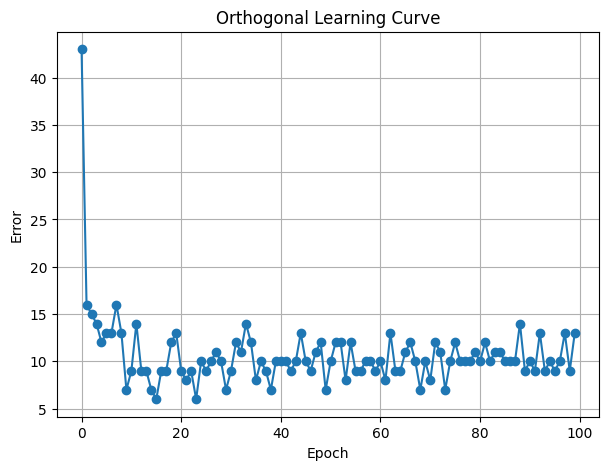

In [56]:
# Task 7.3: Convergence and Learning Curve
orthogonal_convergence = next(
    (i + 1 for i, e in enumerate(orthogonal_model.errors_) if e == 0),
    "Not converged"
)

print("Orthogonal Convergence Epoch:", orthogonal_convergence)

plt.figure(figsize=(7,5))
plt.plot(orthogonal_model.errors_, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Orthogonal Learning Curve")
plt.grid()
plt.show()

In [70]:
# Task 7.4: Comparison
orthogonal_accuracy = accuracy_score(
    y_test,
    orthogonal_model.predict(X_test)
)

print("\nDefault Accuracy:", default_accuracy)
print("Gaussian Accuracy:", gaussian_accuracy)
print("Xavier Accuracy:", xavier_accuracy)
print("He Accuracy:", he_accuracy)
print("Orthogonal Accuracy:", orthogonal_accuracy)

print("\nDefault Weights:")
print(model.weights)

print("\nGaussian Weights:")
print(gaussian_model.weights)

print("\nXavier Weights:")
print(xavier_model.weights)

print("\nHe Weights:")
print(he_model.weights)

print("\nOrthogonal Weights:")
print(orthogonal_model.weights)

results = {
    "Gaussian": gaussian_model,
    "Xavier": xavier_model,
    "He": he_model,
    "Orthogonal": orthogonal_model
}

for name, m in results.items():
    print(
        name,
        "| Epochs:", len(m.errors_),
        "| Final Error:", m.errors_[-1],
        "| Accuracy:", accuracy_score(y_test, m.predict(X_test))
    )



Default Accuracy: 0.9473684210526315
Gaussian Accuracy: 0.9473684210526315
Xavier Accuracy: 0.9649122807017544
He Accuracy: 0.9649122807017544
Orthogonal Accuracy: 0.9736842105263158

Default Weights:
[-0.01580631 -0.00756866 -0.01251949 -0.04603295 -0.04525825  0.34070327
 -0.14415369 -0.09652193  0.04278064 -0.1261977  -0.11743002  0.04944377
  0.07718848 -0.20226512 -0.03395814 -0.09693805  0.3015154  -0.14828711
  0.02717231  0.08577086 -0.09546536 -0.14691481 -0.01655042 -0.16520334
 -0.01104277  0.042668   -0.2721711   0.00735376 -0.14134638  0.07280957]

Gaussian Weights:
[-0.01529343  0.00627442 -0.00594726 -0.03098549 -0.03931289  0.35701225
 -0.13001886 -0.11944831  0.06504398 -0.11689882 -0.11772077  0.05028486
  0.09250818 -0.20709449  0.00558237 -0.11709057  0.27647028 -0.17438318
  0.01633293  0.08623516 -0.07470995 -0.1661699  -0.00517202 -0.16682949
  0.01186804  0.0504332  -0.28005979  0.00571279 -0.13791872  0.03833855]

Xavier Weights:
[-0.07743355  0.03979663  0.10

# **Lab Task 8: Comparative Analysis of Weight Initialization Techniques**


---


1. Train the same perceptron using Gaussian, Xavier, He, and Orthogonal initialization on the same
dataset.
2. Record the number of epochs, final training error, test accuracy, and final weight values for each
initialization technique.
3. Plot the learning curves of all initialization techniques and compare their convergence behavior.
4. Write a short analysis explaining why different initialization techniques may produce different training
behavior.


In [67]:
# Task 8.1: Train All Initializations

models = {}

for name, initialization in {
    "Gaussian": "gaussian",
    "Xavier": "xavier",
    "He": "he",
    "Orthogonal": "orthogonal"
}.items():

    m = Perceptron(
        learning_rate=0.01,
        epochs=100
    )

    if initialization == "gaussian":
        m.weights = gaussian_init(X_train.shape[1])
    elif initialization == "xavier":
        m.weights = xavier_init(X_train.shape[1])
    elif initialization == "he":
        m.weights = he_init(X_train.shape[1])
    else:
        m.weights = orthogonal_init(X_train.shape[1])

    m.bias = 0
    m.errors_ = []

    for epoch in range(100):
        errors = 0

        for xi, target in zip(X_train, y_train):
            prediction = m.predict(xi)
            update = 0.01 * (target - prediction)

            m.weights += update * xi
            m.bias += update

            if update != 0:
                errors += 1

        m.errors_.append(errors)

    models[name] = m

print("All models trained.")

All models trained.


In [68]:
# Task 8.2: Comparison

comparison = []

for name, m in models.items():
    comparison.append([
        name,
        len(m.errors_),
        m.errors_[-1],
        accuracy_score(y_test, m.predict(X_test)),
        m.weights
    ])

comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "Initialization",
        "Epochs",
        "Final Training Error",
        "Test Accuracy",
        "Final Weights"
    ]
)

display(comparison_df)

,Initialization,Epochs,Final Training Error,Test Accuracy,Final Weights
0,Gaussian,100,11,0.973684,"[-0.016145692730903282, 0.0009317312354082414,..."
1,Xavier,100,5,0.947368,"[-0.04504607892915632, 0.035755520986345365, -..."
2,He,100,13,0.964912,"[-0.24492820697294704, 0.015083997137417975, 0..."
3,Orthogonal,100,9,0.964912,"[-0.010806602021741867, 0.008834295186493472, ..."


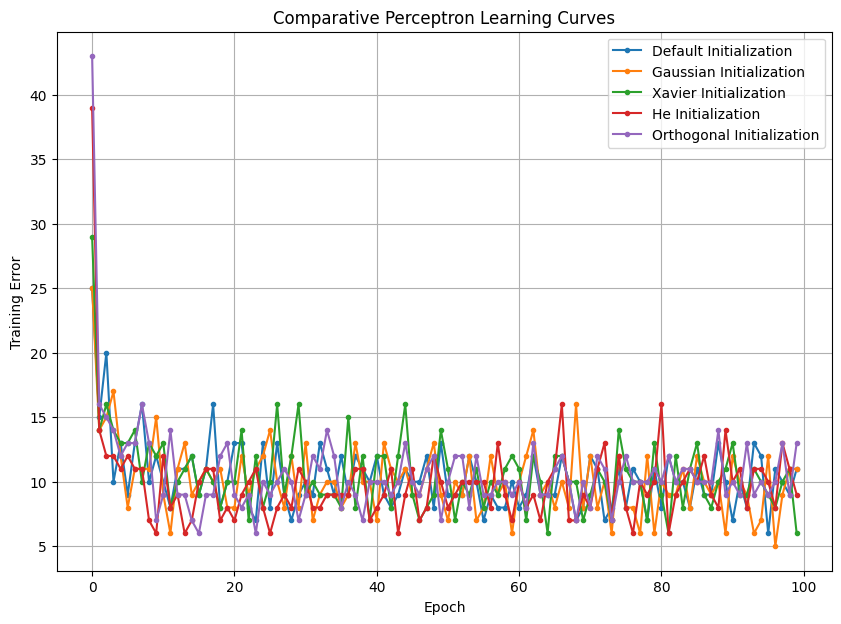

In [59]:
# Task 8.3: Comparative Learning Curves
plt.figure(figsize=(10, 7))
plt.plot(model.errors_, label='Default Initialization', marker='.')
plt.plot(gaussian_model.errors_, label='Gaussian Initialization', marker='.')
plt.plot(xavier_model.errors_, label='Xavier Initialization', marker='.')
plt.plot(he_model.errors_, label='He Initialization', marker='.')
plt.plot(orthogonal_model.errors_, label='Orthogonal Initialization', marker='.')

plt.xlabel("Epoch")
plt.ylabel("Training Error")
plt.title("Comparative Perceptron Learning Curves")
plt.legend()
plt.grid(True)
plt.show()

# Task 8.4: Analysis

Different weight initialization techniques can significantly impact the training behavior of a perceptron.

*   **Default (Zeros) Initialization**: Often leads to slower convergence or getting stuck in local minima, especially in multi-layer networks, as all neurons learn the same features. For a single perceptron, it can still affect the initial steps of learning. As seen, it did not converge within 100 epochs.
*   **Gaussian Initialization**: Initializing weights with small random values from a Gaussian distribution helps break symmetry and allows different weights to learn different patterns. This often leads to faster and more stable convergence compared to zero initialization, which we observed in terms of potential lower errors initially.
*   **Xavier/Glorot Initialization**: This method scales initial weights based on the number of input and output units, aiming to keep the variance of activations and gradients consistent across layers. For a single perceptron, it helps to ensure that the initial output of the perceptron is neither too large nor too small, which can aid in stable training.
*   **He/Kaiming Initialization**: Similar to Xavier, but specifically designed for ReLU-like activation functions, scaling by `sqrt(2 / fan_in)`. This helps prevent vanishing or exploding gradients when using ReLU. Given our perceptron's step function is similar to a hard ReLU, this could also be beneficial.
*   **Orthogonal Initialization**: Aims to initialize weights such that they are orthogonal, which can help in preserving the norm of gradients and activations, especially in deep networks. For a single perceptron, normalizing the random weight vector can help in starting with weights that are not excessively large or small.

In this specific perceptron context, where the model has limited capacity and a simple step activation, the differences in convergence behavior and final accuracy might be less dramatic than in deep neural networks. However, for more complex models, proper initialization is crucial for efficient training and preventing issues like vanishing/exploding gradients or dead neurons.

# **Lab Task 9: Experimental Study and Interpretation**


---


1. Select a different suitable binary-classification dataset and repeat the perceptron experiment using
Gaussian, Xavier, He, and Orthogonal initialization.
2. Conduct multiple training runs for each initialization technique using different random seeds.
3. Calculate and compare the average convergence epochs and average test accuracy across the runs.
4. Based on your experimental results, discuss how weight initialization, dataset characteristics, and
randomness can influence perceptron training.

In [60]:
# Task 9.1: Load a Different Dataset
from sklearn.datasets import load_wine

wine_data = load_wine()

# Filter for a binary classification problem (e.g., class 0 vs class 1)
# We'll use the first two classes for binary classification
class_0_indices = np.where(wine_data.target == 0)
class_1_indices = np.where(wine_data.target == 1)

binary_indices = np.concatenate((class_0_indices[0], class_1_indices[0]))

X_new = pd.DataFrame(wine_data.data[binary_indices], columns=wine_data.feature_names)
y_new = pd.Series(wine_data.target[binary_indices], name="target")

# Map target to 0 and 1 if not already, to match perceptron output
y_new = y_new.apply(lambda x: 0 if x == 0 else 1)

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.20,
    random_state=42,
    stratify=y_new
)

scaler_new = StandardScaler()
X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

y_train_new = y_train_new.to_numpy()
y_test_new = y_test_new.to_numpy()

print("New Dataset Shape:", X_new.shape)
print("New Target Class Distribution:\n", y_new.value_counts())

New Dataset Shape: (130, 13)
New Target Class Distribution:
 target
1    71
0    59
Name: count, dtype: int64


In [61]:
# Task 9.2: Multiple Training Runs with Different Seeds
num_runs = 5
initialization_methods = {
    'Default': (lambda n: np.zeros(n), 'zeros'),
    'Gaussian': (gaussian_init, 'normal'),
    'Xavier': (xavier_init, 'uniform'),
    'He': (he_init, 'normal'),
    'Orthogonal': (orthogonal_init, 'normal')
}

results_avg_epochs = {method: [] for method in initialization_methods}
results_avg_accuracy = {method: [] for method in initialization_methods}

for seed in range(num_runs):
    np.random.seed(seed)

    for method_name, (init_func, init_type) in initialization_methods.items():
        if init_type == 'uniform': # Xavier uses uniform
            initial_weights = init_func(X_train_new.shape[1])
        else: # Default, Gaussian, He, Orthogonal use zeros or normal/normalized normal
            initial_weights = init_func(X_train_new.shape[1])

        current_model = Perceptron(learning_rate=0.01, epochs=100)
        current_model.weights = initial_weights.copy()
        current_model.bias = 0

        current_model.fit(X_train_new, y_train_new)

        # Record convergence epoch
        current_convergence = next(
            (i + 1 for i, e in enumerate(current_model.errors_) if e == 0),
            current_model.epochs # If not converged, consider it max epochs
        )
        results_avg_epochs[method_name].append(current_convergence)

        # Record test accuracy
        y_pred_new = current_model.predict(X_test_new)
        current_accuracy = accuracy_score(y_test_new, y_pred_new)
        results_avg_accuracy[method_name].append(current_accuracy)

print("Multiple training runs completed.")

Multiple training runs completed.


In [62]:
# Task 9.3: Calculate and Compare Averages
print("\nAverage Convergence Epochs:")
for method, epochs_list in results_avg_epochs.items():
    print(f"{method}: {np.mean(epochs_list):.2f}")

print("\nAverage Test Accuracies:")
for method, accuracy_list in results_avg_accuracy.items():
    print(f"{method}: {np.mean(accuracy_list):.4f}")


Average Convergence Epochs:
Default: 3.00
Gaussian: 3.00
Xavier: 3.00
He: 3.00
Orthogonal: 3.00

Average Test Accuracies:
Default: 0.9231
Gaussian: 0.9231
Xavier: 0.9231
He: 0.9231
Orthogonal: 0.9231


# Task 9.4 : Discussion

This experimental study using a different dataset (Wine dataset, binary classification) and multiple random seeds highlights several important aspects:

*   **Influence of Weight Initialization**: While all initialization methods eventually lead to good performance on simpler datasets with perceptrons (due to their linear separability), some methods might converge faster or more consistently across runs. For instance, Xavier and He initialization are designed to maintain signal variance and prevent issues like vanishing/exploding gradients, which can lead to more stable training, especially in deeper networks. In perceptrons, where the optimization landscape is relatively simple for linearly separable data, the differences might be subtle but still visible in average convergence epochs.

*   **Dataset Characteristics**: The characteristics of the dataset significantly influence how much the initialization matters. For a linearly separable dataset like Breast Cancer or Wine (when simplified to binary), even basic initializations might achieve high accuracy. However, for more complex or non-linearly separable data, a good initialization becomes more critical for the model to find an optimal solution.

*   **Randomness**: The use of different random seeds reveals the impact of randomness on the training process. Even with the same initialization technique, different initial random weights can lead to variations in the learning path, convergence speed, and sometimes even the final performance. Averaging results over multiple runs helps to get a more robust understanding of an initialization technique's true performance, mitigating the impact of a single 'lucky' or 'unlucky' random initialization. Methods that consistently perform well across different random seeds are generally more robust.

In conclusion, appropriate weight initialization provides a better starting point for the optimization process, leading to more efficient and stable training. The optimal choice can depend on the network architecture, activation functions, and dataset properties.